Using device: cpu
[integral-bundle] loaded 'integral_gaussian_L64_N3000_seed20250930.pt'
  n=3000 L=64 kernel=gaussian train=2400 val=300 test=300
  fingerprint: 3db847782db45780f0ecdb1e78a44016989b0855
split sizes | train=2400 val=300 test=300
DeepONet: 230,913 parameters

Training DeepONet
Epoch   1/150 | train 3.830886e-03 | val 4.180760e-04 | t/epoch 0.469s | lr 0.001000
Epoch  10/150 | train 4.292757e-04 | val 1.051382e-04 | t/epoch 0.616s | lr 0.000989
Epoch  20/150 | train 3.680286e-04 | val 2.754148e-04 | t/epoch 0.618s | lr 0.000957
Epoch  30/150 | train 2.583805e-04 | val 1.999432e-04 | t/epoch 0.650s | lr 0.000905
Epoch  40/150 | train 2.552574e-04 | val 1.042381e-04 | t/epoch 0.674s | lr 0.000835
Epoch  50/150 | train 2.227204e-04 | val 4.131884e-05 | t/epoch 0.701s | lr 0.000750
Epoch  60/150 | train 2.019589e-04 | val 1.040940e-04 | t/epoch 0.988s | lr 0.000655
Epoch  70/150 | train 1.823715e-04 | val 1.303520e-04 | t/epoch 0.714s | lr 0.000552
Epoch  80/150 | train 2.052

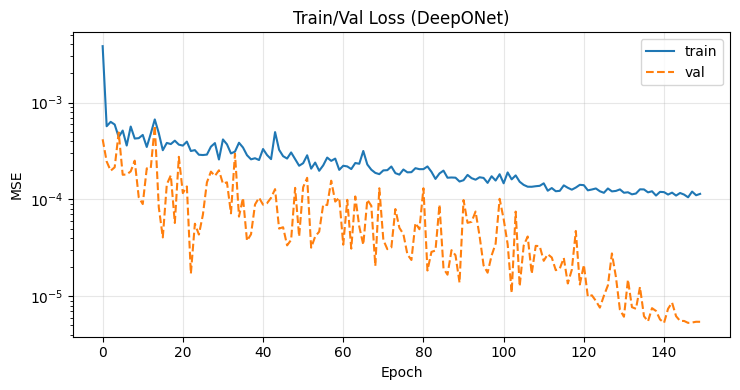

test MSE | DeepONet: 5.507612e-06


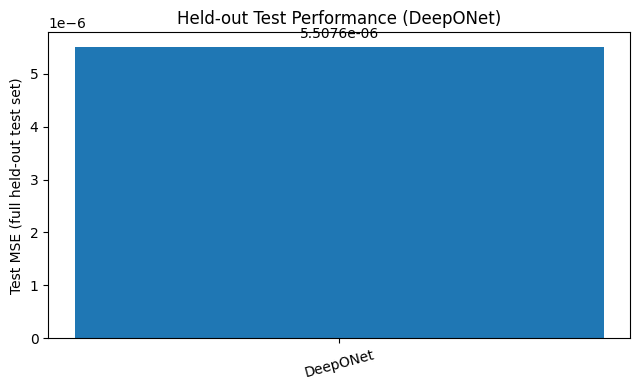


=== FLOPs (per forward, single sample) & Test MSE ===
Model                                    FLOPs     FLOPs(M)     Test MSE
DeepONet                             6,743,680        6.744   5.5076e-06

--- Testing at resolution 32 ---
  DeepONet: 0.023598

--- Testing at resolution 48 ---
  DeepONet: 0.023756

--- Testing at resolution 64 ---
  DeepONet: 0.023816

--- Testing at resolution 96 ---
  DeepONet: 0.023849

--- Testing at resolution 128 ---
  DeepONet: 0.023865

--- Testing at resolution 256 ---
  DeepONet: 0.023878


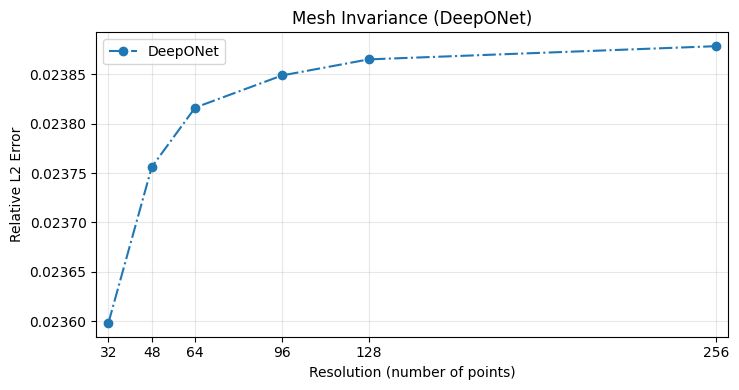

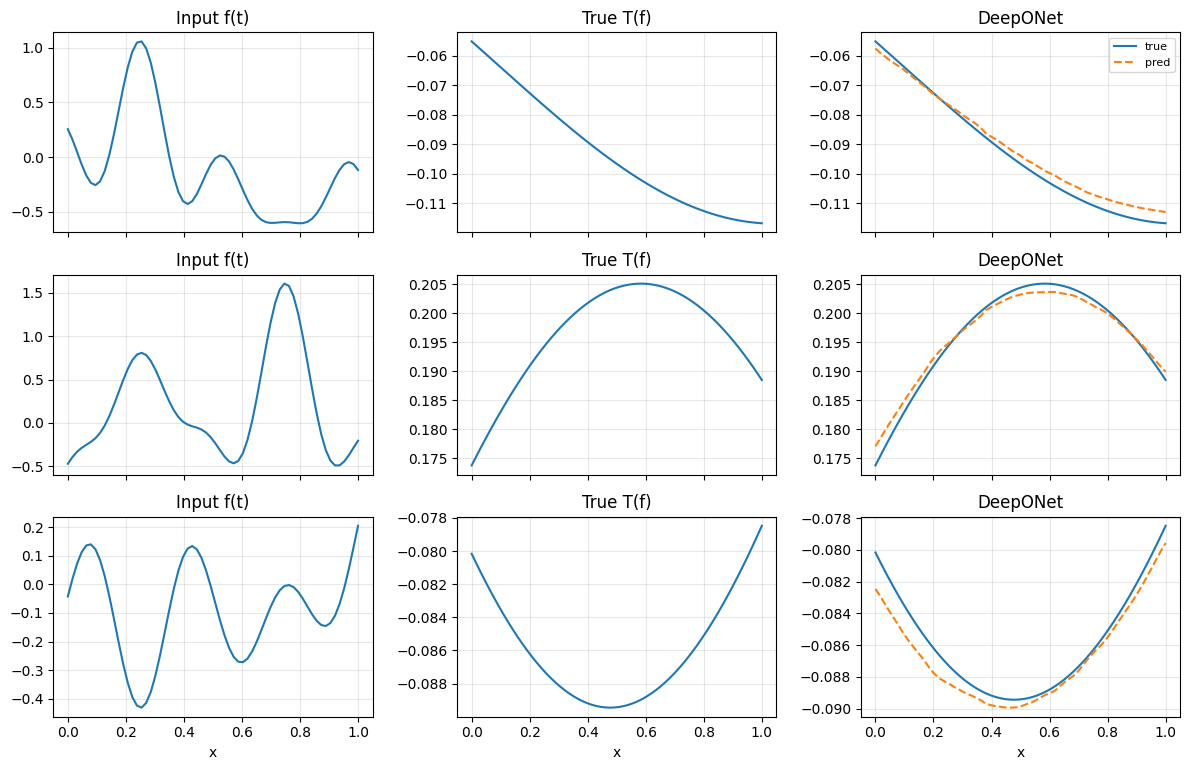

In [ ]:
import os
import time
import math
import hashlib
import random
from typing import Iterable

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt




def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(42)


# Fixed coefficient-based data generation

def eval_integral_basis(coeffs: torch.Tensor, n_points: int) -> torch.Tensor:

    single = coeffs.dim() == 1
    if single:
        coeffs = coeffs.unsqueeze(0)

    coeffs = coeffs.float()
    t = torch.linspace(0.0, 1.0, n_points, dtype=coeffs.dtype, device=coeffs.device)

    f = (
        coeffs[:, 0:1] * torch.sin(2 * math.pi * t)
        + coeffs[:, 1:2] * torch.cos(4 * math.pi * t)
        + coeffs[:, 2:3] * torch.exp(-8 * (t - 0.3) ** 2)
        + coeffs[:, 3:4] * torch.exp(-8 * (t - 0.7) ** 2)
        + coeffs[:, 4:5] * t * (1 - t)
        + coeffs[:, 5:6] * torch.sin(6 * math.pi * t)
        + coeffs[:, 6:7] * (t - 0.5) ** 3
        + coeffs[:, 7:8] * torch.cos(8 * math.pi * t)
    )

    return f.squeeze(0) if single else f


def make_kernel_1d(n_points: int, kernel_type: str = "gaussian") -> torch.Tensor:
    x = torch.linspace(0.0, 1.0, n_points)
    t = torch.linspace(0.0, 1.0, n_points)
    X, T = torch.meshgrid(x, t, indexing="ij")

    if kernel_type == "gaussian":
        return torch.exp(-((X - T) ** 2) / 2)
    if kernel_type == "exponential":
        return torch.exp(-5 * torch.abs(X - T))
    if kernel_type == "polynomial":
        return (1 + X * T) * torch.exp(-2 * (X - T) ** 2)

    raise ValueError(f"Unknown kernel_type: {kernel_type}")


def trapezoid_weights(n_points: int) -> torch.Tensor:
    dx = 1.0 / max(1, n_points - 1)
    w = torch.full((n_points,), dx)
    if n_points > 1:
        w[0] *= 0.5
        w[-1] *= 0.5
    return w


def apply_integral_operator(f: torch.Tensor, kernel_type: str = "gaussian") -> torch.Tensor:
    """
    Apply T_K f(x) = int_0^1 K(x,t) f(t) dt using trapezoidal quadrature.

    f: (L,) or (N, L)
    """
    single = f.dim() == 1
    if single:
        f = f.unsqueeze(0)

    f = f.float()
    n_points = f.shape[-1]
    K = make_kernel_1d(n_points, kernel_type).to(dtype=f.dtype, device=f.device)
    w = trapezoid_weights(n_points).to(dtype=f.dtype, device=f.device)
    A = K * w.view(1, -1)
    out = f @ A.T

    return out.squeeze(0) if single else out


def _bundle_fingerprint(functions: torch.Tensor, first_idxs=(0, 1, 2, 10, 222, 299)) -> str:
    h = hashlib.sha1()
    for i in first_idxs:
        if 0 <= i < functions.shape[0]:
            h.update(functions[i].detach().cpu().numpy().astype(np.float32).tobytes())
    return h.hexdigest()


class IntegralBundleDataset(Dataset):

    def __init__(self, bundle: dict, split: str | None = None):
        self.coeffs = bundle["coeffs"].float()
        self.functions = bundle["functions"].float()
        self.outputs = bundle["outputs"].float()
        self.n_points = int(bundle["n_points"])
        self.kernel_type = str(bundle["kernel_type"])
        self.fingerprint = bundle.get("fingerprint", None)

        if split is None:
            self.indices = torch.arange(len(self.functions))
        else:
            if split not in bundle["splits"]:
                raise KeyError(f"Unknown split '{split}'. Expected one of {list(bundle['splits'].keys())}.")
            self.indices = bundle["splits"][split].long()

    def __len__(self) -> int:
        return len(self.indices)

    def __getitem__(self, idx: int):
        real_idx = int(self.indices[idx])
        return self.functions[real_idx], self.outputs[real_idx]

    def get_coeffs(self, idx: int) -> torch.Tensor:
        real_idx = int(self.indices[idx])
        return self.coeffs[real_idx]


def get_or_create_integral_bundle(
    path: str,
    *,
    n_samples: int,
    n_points: int,
    kernel_type: str,
    sample_seed: int,
    train_ratio: float = 0.8,
    val_ratio: float = 0.1,
) -> dict:
    """
    train=2400, val=300, test=300.
    """
    if os.path.exists(path):
        bundle = torch.load(path, map_location="cpu")
        print(f"[integral-bundle] loaded '{path}'")
        print(
            f"  n={len(bundle['functions'])} L={bundle['n_points']} kernel={bundle['kernel_type']} "
            f"train={len(bundle['splits']['train'])} val={len(bundle['splits']['val'])} test={len(bundle['splits']['test'])}"
        )
        if "fingerprint" in bundle:
            print("  fingerprint:", bundle["fingerprint"])
        return bundle

    print(f"[integral-bundle] creating '{path}'")
    coeff_gen = torch.Generator().manual_seed(int(sample_seed))
    split_gen = torch.Generator().manual_seed(int(sample_seed) + 999)

    coeffs = torch.randn(n_samples, 8, generator=coeff_gen) * 0.3
    functions = eval_integral_basis(coeffs, n_points).cpu()
    outputs = apply_integral_operator(functions, kernel_type).cpu()

    perm = torch.randperm(n_samples, generator=split_gen)
    n_train = int(train_ratio * n_samples)
    n_val = int(val_ratio * n_samples)
    train_idx = perm[:n_train]
    val_idx = perm[n_train:n_train + n_val]
    test_idx = perm[n_train + n_val:]

    bundle = {
        "coeffs": coeffs.cpu(),
        "functions": functions.cpu(),
        "outputs": outputs.cpu(),
        "n_points": int(n_points),
        "kernel_type": str(kernel_type),
        "sample_seed": int(sample_seed),
        "fingerprint": _bundle_fingerprint(functions),
        "splits": {
            "train": train_idx.cpu(),
            "val": val_idx.cpu(),
            "test": test_idx.cpu(),
        },
    }

    torch.save(bundle, path)
    print(
        f"[integral-bundle] saved '{path}' | n={n_samples} L={n_points} kernel={kernel_type} "
        f"train={len(train_idx)} val={len(val_idx)} test={len(test_idx)}"
    )
    print("  fingerprint:", bundle["fingerprint"])
    return bundle


# DeepONet model

class DeepONet(nn.Module):
    """
    DeepONet for learning integral operators.
    Branch net encodes f on the training grid; trunk net encodes query locations x.
    """
    def __init__(
        self,
        n_points: int = 64,
        branch_width: int = 256,
        trunk_width: int = 128,
        latent_dim: int = 128,
        branch_depth: int = 4,
        trunk_depth: int = 4,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.n_points = n_points
        self.latent_dim = latent_dim

        branch_layers = [nn.Linear(n_points, branch_width), nn.ReLU()]
        for _ in range(branch_depth - 2):
            branch_layers += [nn.Linear(branch_width, branch_width), nn.ReLU(), nn.Dropout(dropout)]
        branch_layers += [nn.Linear(branch_width, latent_dim)]
        self.branch_net = nn.Sequential(*branch_layers)

        trunk_layers = [nn.Linear(1, trunk_width), nn.ReLU()]
        for _ in range(trunk_depth - 2):
            trunk_layers += [nn.Linear(trunk_width, trunk_width), nn.ReLU(), nn.Dropout(dropout)]
        trunk_layers += [nn.Linear(trunk_width, latent_dim)]
        self.trunk_net = nn.Sequential(*trunk_layers)

        self.bias = nn.Parameter(torch.zeros(1))

    def forward(self, f: torch.Tensor, x: torch.Tensor | None = None) -> torch.Tensor:
        """
        f: (B, n_points) branch input on the training grid.
        x: (N,) query locations in [0,1]. If None, use the training grid.
        return: (B, N)
        """
        if x is None:
            x = torch.linspace(0.0, 1.0, self.n_points, device=f.device)
        branch_features = self.branch_net(f)
        x_input = x.unsqueeze(-1)
        trunk_features = self.trunk_net(x_input)
        output = torch.einsum("bl,nl->bn", branch_features, trunk_features) + self.bias
        return output


# Training and evaluation

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running = 0.0
    for f, y in loader:
        f, y = f.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        yhat = model(f)
        loss = criterion(yhat, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        running += loss.item()
    return running / max(1, len(loader))


def evaluate(model, loader, criterion, device):
    model.eval()
    total = 0.0
    with torch.no_grad():
        for f, y in loader:
            f, y = f.to(device), y.to(device)
            yhat = model(f)
            total += criterion(yhat, y).item()
    return total / max(1, len(loader))


def train_model(model, train_loader, val_loader, epochs=150, lr=1e-3, device="cpu"):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.MSELoss()
    hist = {"train_loss": [], "val_loss": [], "epoch_time": [], "lr": []}

    for ep in range(1, epochs + 1):
        t0 = time.perf_counter()
        tr = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va = evaluate(model, val_loader, criterion, device)
        scheduler.step()
        dt = time.perf_counter() - t0

        hist["train_loss"].append(tr)
        hist["val_loss"].append(va)
        hist["epoch_time"].append(dt)
        hist["lr"].append(optimizer.param_groups[0]["lr"])

        if ep % 10 == 0 or ep == 1:
            print(
                f"Epoch {ep:3d}/{epochs} | train {tr:.6e} | val {va:.6e} | "
                f"t/epoch {dt:.3f}s | lr {hist['lr'][-1]:.6f}"
            )

    return hist


def evaluate_full_dataset(model, loader, device="cpu") -> float:
    """Compute MSE over the entire held-out test set at the training grid."""
    model.eval()
    se_sum = 0.0
    count = 0

    with torch.no_grad():
        for f, y in loader:
            f, y = f.to(device), y.to(device)
            yhat = model(f)
            se_sum += F.mse_loss(yhat, y, reduction="sum").item()
            count += y.numel()

    return se_sum / max(1, count)


# Plot helpers

def plot_train_val(hist):
    plt.figure(figsize=(7.5, 4))
    plt.plot(hist["train_loss"], label="train")
    plt.plot(hist["val_loss"], label="val", linestyle="--")
    plt.yscale("log")
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.title("Train/Val Loss (DeepONet)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()


def bar_test_mse(results):
    names = list(results.keys())
    vals = [results[n] for n in names]
    plt.figure(figsize=(6.5, 4))
    plt.bar(names, vals)
    for i, v in enumerate(vals):
        plt.text(i, v * 1.02, f"{v:.4e}", ha="center", va="bottom")
    plt.ylabel("Test MSE (full held-out test set)")
    plt.title("Held-out Test Performance (DeepONet)")
    plt.xticks(rotation=15)
    plt.tight_layout()


def plot_test_examples(model, dataset, n_show=4, device="cpu", idxs=None, seed=12345):
    if idxs is None:
        rng = np.random.default_rng(seed)
        idxs = rng.choice(len(dataset), n_show, replace=False)
    else:
        idxs = list(idxs)

    fig, axes = plt.subplots(n_show, 3, figsize=(12, 2.6 * n_show), sharex=True)
    if n_show == 1:
        axes = axes.reshape(1, -1)
    xs = torch.linspace(0.0, 1.0, dataset.n_points)

    with torch.no_grad():
        for i, idx in enumerate(idxs):
            f, y = dataset[int(idx)]
            yhat = model(f.unsqueeze(0).to(device)).squeeze(0).cpu()
            axes[i, 0].plot(xs, f)
            axes[i, 0].set_title("Input f(t)")
            axes[i, 0].grid(True, alpha=0.3)
            axes[i, 1].plot(xs, y)
            axes[i, 1].set_title("True T(f)")
            axes[i, 1].grid(True, alpha=0.3)
            axes[i, 2].plot(xs, y, label="true")
            axes[i, 2].plot(xs, yhat, linestyle="--", label="pred")
            axes[i, 2].set_title("DeepONet")
            axes[i, 2].grid(True, alpha=0.3)
            if i == 0:
                axes[i, 2].legend(fontsize=8)
    for k in range(3):
        axes[-1, k].set_xlabel("x")
    plt.tight_layout()


# Mesh-invariance evaluation for DeepONet

def resample_1d(vec: torch.Tensor, new_len: int) -> torch.Tensor:
    x = vec.view(1, 1, -1)
    return F.interpolate(x, size=new_len, mode="linear", align_corners=True).view(-1)


def relative_l2_weighted(pred: torch.Tensor, target: torch.Tensor, eps: float = 1e-12) -> float:
    L = pred.numel()
    dx = 1.0 / max(1, L - 1)
    w = pred.new_ones(L)
    if L > 1:
        w[0] = 0.5
        w[-1] = 0.5

    def weighted_norm(x):
        return torch.sqrt(((x ** 2) * w).sum() * dx)

    diff_norm = weighted_norm(pred - target)
    target_norm = weighted_norm(target)
    if target_norm < eps:
        return diff_norm.item()
    return (diff_norm / (target_norm + eps)).item()


def mesh_invariance_from_coeffs_deeponet(
    model: DeepONet,
    test_dataset: IntegralBundleDataset,
    kernel_type: str,
    grid_list: Iterable[int],
    n_per_res: int,
    train_len: int,
    device,
):
    """
    Evaluate the same held-out continuous functions at multiple output resolutions.

    DeepONet branch input remains on the training grid of length train_len.
    The trunk is queried at each target grid resolution.
    """
    results = []
    n_use = min(n_per_res, len(test_dataset))
    coeffs = torch.stack([test_dataset.get_coeffs(i) for i in range(n_use)])

    # Branch input is fixed at the training grid for all resolutions.
    f_branch = eval_integral_basis(coeffs, train_len).cpu().to(device)

    model.eval()
    for n_points in grid_list:
        print(f"\n--- Testing at resolution {n_points} ---")
        f_test = eval_integral_basis(coeffs, n_points).cpu()
        y_true = apply_integral_operator(f_test, kernel_type).cpu()
        x_grid = torch.linspace(0.0, 1.0, n_points, device=device)

        errs = []
        with torch.no_grad():
            for i in range(n_use):
                y_hat = model(f_branch[i:i + 1], x_grid).squeeze(0).cpu()
                errs.append(relative_l2_weighted(y_hat, y_true[i]))

        avg_err = float(np.mean(errs))
        results.append(avg_err)
        print(f"  DeepONet: {avg_err:.6f}")

    return results


def plot_mesh_invariance(grid_list, vals, title="Mesh Invariance (DeepONet)"):
    plt.figure(figsize=(7.5, 4))
    plt.plot(grid_list, vals, marker="o", linestyle="-.", label="DeepONet")
    plt.xlabel("Resolution (number of points)")
    plt.ylabel("Relative L2 Error")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.xticks(grid_list, [str(x) for x in grid_list])
    plt.margins(x=0.02)
    plt.tight_layout()

# FLOPs estimator for DeepONet

def _count_linear_flops(in_features: int, out_features: int, batch: int = 1) -> int:
    macs = in_features * out_features * batch
    return 2 * macs + out_features * batch


def estimate_flops_deeponet(model: DeepONet, n_points: int) -> int:
    branch_flops = 0
    last_out = None
    for m in model.branch_net:
        if isinstance(m, nn.Linear):
            out_f, in_f = m.weight.shape
            branch_flops += _count_linear_flops(in_f, out_f, batch=1)
            last_out = out_f
        elif isinstance(m, nn.ReLU) and last_out is not None:
            branch_flops += last_out

    trunk_flops = 0
    last_out = None
    for m in model.trunk_net:
        if isinstance(m, nn.Linear):
            out_f, in_f = m.weight.shape
            trunk_flops += _count_linear_flops(in_f, out_f, batch=n_points)
            last_out = out_f
        elif isinstance(m, nn.ReLU) and last_out is not None:
            trunk_flops += last_out * n_points

    L = model.latent_dim
    einsum_flops = (2 * L - 1) * n_points
    bias_adds = n_points
    return int(branch_flops + trunk_flops + einsum_flops + bias_adds)


def print_flops_mse_table(model: DeepONet, test_mse: float, n_points: int):
    flops = estimate_flops_deeponet(model, n_points)
    print("\n=== FLOPs (per forward, single sample) & Test MSE ===")
    print(f"{'Model':30s} {'FLOPs':>15s} {'FLOPs(M)':>12s} {'Test MSE':>12s}")
    print(f"{'DeepONet':30s} {flops:15,d} {flops / 1e6:12.3f} {test_mse:12.4e}")


# Main
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    # Data
    N_SAMPLES = 3000
    N_POINTS = 64
    KERNEL = "gaussian"  # "gaussian" | "exponential" | "polynomial"
    BATCH = 32
    BUNDLE_PATH = "integral_gaussian_L64_N3000_seed20250930.pt"

    bundle = get_or_create_integral_bundle(
        BUNDLE_PATH,
        n_samples=N_SAMPLES,
        n_points=N_POINTS,
        kernel_type=KERNEL,
        sample_seed=20250930,
        train_ratio=0.8,
        val_ratio=0.1,
    )

    train_ds = IntegralBundleDataset(bundle, split="train")
    val_ds = IntegralBundleDataset(bundle, split="val")
    test_ds = IntegralBundleDataset(bundle, split="test")

    print(f"split sizes | train={len(train_ds)} val={len(val_ds)} test={len(test_ds)}")

    train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=BATCH, shuffle=False)

    # Model
    model = DeepONet(
        n_points=N_POINTS,
        branch_width=256,
        trunk_width=128,
        latent_dim=128,
        branch_depth=4,
        trunk_depth=4,
        dropout=0.1,
    ).to(device)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"DeepONet: {n_params:,} parameters")

    # Train
    print("\n" + "=" * 60)
    print("Training DeepONet")
    print("=" * 60)
    hist = train_model(model, train_loader, val_loader, epochs=150, lr=1e-3, device=device)
    plot_train_val(hist)
    plt.show()

    # Full held-out evaluation
    mse = evaluate_full_dataset(model, test_loader, device=device)
    print(f"test MSE | DeepONet: {mse:.6e}")
    bar_test_mse({"DeepONet": mse})
    plt.show()

    # FLOPs
    print_flops_mse_table(model, mse, n_points=N_POINTS)

    # Mesh invariance using same held-out coefficient vectors
    RES_LIST = [32, 48, 64, 96, 128, 256]
    mi_vals = mesh_invariance_from_coeffs_deeponet(
        model,
        test_dataset=test_ds,
        kernel_type=KERNEL,
        grid_list=RES_LIST,
        n_per_res=100,
        train_len=N_POINTS,
        device=device,
    )
    plot_mesh_invariance(RES_LIST, mi_vals, title="Mesh Invariance (DeepONet)")
    plt.show()

    # Qualitative test examples
    plot_test_examples(model, test_ds, n_show=3, device=device, idxs=[10, 30, 150])
    plt.show()


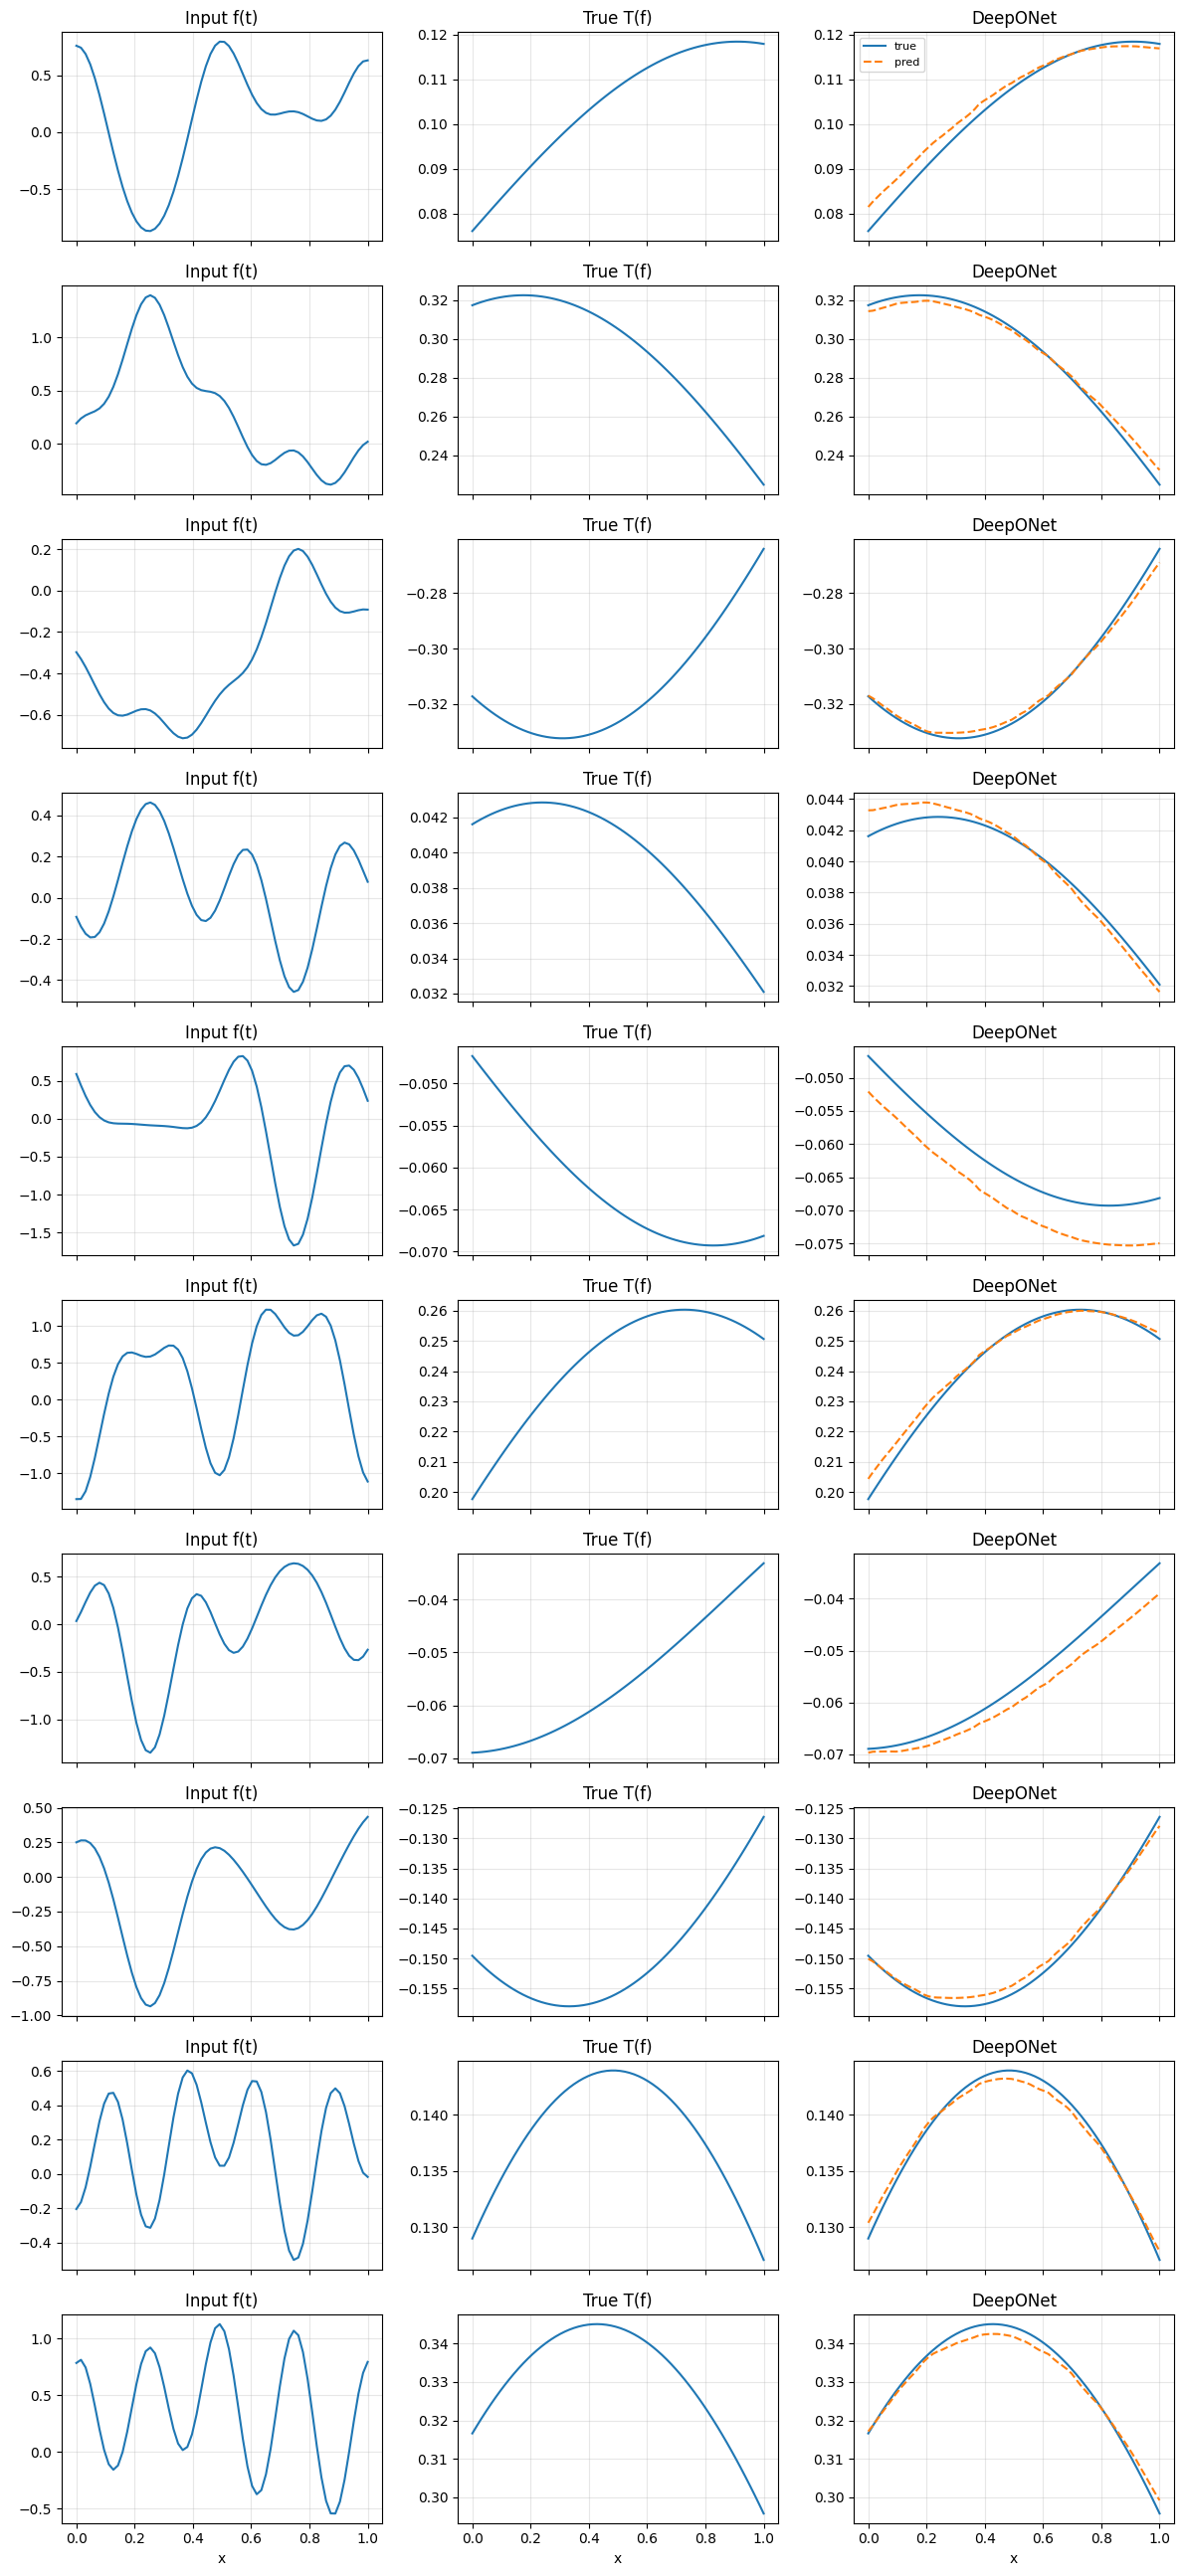

In [ ]:
plot_test_examples(model, test_ds, n_show=10, device=device, idxs=[238,
256,
276,
15,
69,
190,
59,
293,
298,
79])
plt.show()